# Notebook 03: Competición — Redes Recurrentes (LSTM)

Entrenamos una red **LSTM** sobre las 16 combinaciones de ventanas
y comparamos los resultados con los obtenidos con el MLP del notebook 02.

## Hipótesis

El MLP aplana la entrada y pierde el orden temporal. La LSTM procesa
los datos día a día en orden, acumulando memoria del pasado. Si existen
dependencias temporales en los retornos, la LSTM debería capturarlas
y mejorar el MAE del MLP.

## Estructura

1. Configuración e imports
2. Datos y referencias
3. Arquitectura LSTM [64, 32]
4. Entrenamiento: 16 combinaciones
5. Resultados y conclusiones

## Configuración

| Parámetro | Valor |
|---|---|
| Arquitectura | LSTM [64, 32] |
| `lr` | 1e-5 |
| `Dropout` | 0.2 |
| `batch_size` | 32 |
| `min_epochs` | 100 |
| `patience` | 30 |
| `epochs máx` | 300 |


## 1. Configuración e imports

In [1]:
import sys, os, random, warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

# ── Raíz del proyecto al path ─────────────────────────────────
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ── Módulos del proyecto ──────────────────────────────────────
from src.data       import cargar_returns, preparar_datos, TICKERS
from src.models     import build_lstm_model, contar_parametros
from src.training   import (entrenar_modelo_lr5,
                             EarlyStoppingConMinimo, fijar_semilla)
from src.evaluation import mae_global, construir_matriz_resultados

# ── Semilla global ────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Ventanas del taller ───────────────────────────────────────
INPUT_WINDOWS  = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]

# ── Hiperparámetros ───────────────────────────────────────────
LR         = 1e-5
EPOCHS     = 300
MIN_EPOCHS = 100
PATIENCE   = 30
BATCH_SIZE = 32

FIGURES_DIR = project_root / "results" / "figures"
TABLES_DIR  = project_root / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {project_root}")
print(f"Config:   lr={LR}, min_epochs={MIN_EPOCHS}, patience={PATIENCE}")
print("Imports OK")

Proyecto: c:\Users\alons\Desktop\B3_T4\taller-redes-neuronales
Config:   lr=1e-05, min_epochs=100, patience=30
Imports OK


## 2. Datos y referencias

Cargamos los retornos y dos referencias del trabajo anterior:
- **Baselines** (notebook 01): suelo mínimo a superar.
- **MLP [64,32]** (notebook 02): benchmark neuronal a mejorar.


In [2]:
returns = cargar_returns(verbose=True)
print(f"Rango: {returns.index.min().date()} → {returns.index.max().date()}")

[cargar_returns] Cargados 16192 días, 23 activos
Rango: 1962-01-03 → 2026-05-05


In [3]:
# Suelo de baselines del notebook 01
baselines_path = TABLES_DIR / "01_baselines.csv"
if baselines_path.exists():
    df_baselines = pd.read_csv(baselines_path)
    suelo = (
        df_baselines.groupby(["V","H"])["MAE_test"]
        .min().reset_index()
        .rename(columns={"MAE_test": "MAE_suelo"})
    )
    print("Baselines cargados OK")
else:
    print("ATENCIÓN: ejecuta primero 01_baselines.ipynb")

# Referencia MLP del notebook 02
mlp_path = TABLES_DIR / "02_densas.csv"
if mlp_path.exists():
    df_mlp_ref = pd.read_csv(mlp_path)
    suelo_mlp = (
        df_mlp_ref.groupby(["V","H"])["MAE_test"]
        .min().reset_index()
        .rename(columns={"MAE_test": "MAE_mlp"})
    )
    print("Referencia MLP cargada OK")
    print("\nMAE MLP [64,32] por combinación (a superar):")
    print(suelo_mlp.pivot(index="V", columns="H", values="MAE_mlp").round(5))
else:
    print("ATENCIÓN: ejecuta primero 02_competicion_densas.ipynb")

Baselines cargados OK
Referencia MLP cargada OK

MAE MLP [64,32] por combinación (a superar):
H        1        5        30       90
V                                     
5   0.01226  0.00559  0.00232  0.00126
10  0.01226  0.00558  0.00232  0.00126
30  0.01227  0.00559  0.00232  0.00126
90  0.01229  0.00560  0.00232  0.00127


## 3. Arquitectura LSTM [64, 32]

### Diferencia fundamental con el MLP

```
Dense [64, 32]:
  Flatten → (V×23,) → Dense(64) → Dense(32) → Dense(23)
  Aplana la entrada: pierde completamente el orden temporal.

LSTM [64, 32]:
  (V, 23) → LSTM(64) → LSTM(32) → Dense(23)
  Procesa día a día en orden: el día 2 se procesa sabiendo
  lo que pasó el día 1, el día 30 con contexto de los 29 anteriores.
```

### Las compuertas de la LSTM

La LSTM resuelve el problema del **vanishing gradient** de las RNN simples
mediante tres compuertas que controlan el flujo de información:

| Compuerta | Función |
|---|---|
| **Forget gate** | ¿Qué del pasado olvidar? |
| **Input gate** | ¿Qué del presente recordar? |
| **Output gate** | ¿Qué enviar al siguiente paso? |

Cada compuerta es una sigmoide (0-1) que actúa como un "grifo".
Esto crea un camino directo para el gradiente → puede aprender
dependencias de cientos de pasos atrás.

### return_sequences

Con dos capas LSTM apiladas, la primera necesita devolver la secuencia
completa para que la segunda pueda procesarla:

```python
LSTM(64, return_sequences=True)   # → (batch, V, 64) a la siguiente LSTM
LSTM(32, return_sequences=False)  # → (batch, 32) al Dense final
Dense(23)                         # → predicción final
```

**Regla**: todas las capas LSTM menos la última llevan `return_sequences=True`.


In [4]:
# Summary de la LSTM [64, 32] para V=30
# Fíjate: no hay Flatten → la secuencia (30, 23) entra intacta
# El factor 4 de la LSTM viene de sus 4 transformaciones internas
modelo_ejemplo = build_lstm_model(
    input_shape=(30, 23),
    units=[64, 32],       # dos capas LSTM apiladas
    dropout=0.2,          # dropout sobre la entrada de cada timestep
    recurrent_dropout=0.0 # sin dropout recurrente (estabilidad)
)
modelo_ejemplo.summary()
print(f"\nTotal parámetros: {contar_parametros(modelo_ejemplo):,}")

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)


Total parámetros: 35,703


### Parámetros LSTM [64,32] vs Dense [64,32]

| Arquitectura | Parámetros | Nota |
|---|---|---|
| Dense [64, 32] | 47.063 | 94% en la primera capa (aplana 690 features) |
| LSTM [64, 32] | 35.703 | Factor 4 interno por las 4 transformaciones |

La LSTM tiene **menos parámetros que el MLP** pero procesa los datos
de forma más estructurada al respetar el orden temporal.

El factor 4 de la LSTM viene de sus 4 transformaciones internas
(forget gate, input gate, cell gate, output gate), cada una con su
propia matriz de pesos de entrada y recurrente.


## 4. Entrenamiento: LSTM [64,32] en 16 combinaciones

Entrenamos la LSTM en las 16 combinaciones con la configuración óptima.
Usamos `dropout=0.2` sobre la entrada de cada timestep.

**Nota sobre regularización en LSTM**:
No aplicamos L2 en los pesos recurrentes porque puede desestabilizar
el entrenamiento. El dropout sobre la entrada es suficiente como
regularización para este problema.

**Tiempo estimado**: ~2-3 horas en CPU.


In [5]:
# Entrenamos LSTM [64,32] en las 16 combinaciones.
# La LSTM procesa cada timestep secuencialmente → más lenta que el MLP
# pero preserva el orden temporal de los retornos.
print("Entrenando LSTM [64,32] en 16 combinaciones...")
print(f"lr={LR}, dropout=0.2, min_epochs={MIN_EPOCHS}, patience={PATIENCE}\n")

resultados_lstm = {}

for V in INPUT_WINDOWS:
    for H in OUTPUT_WINDOWS:
        clave = f"V{V}_H{H}"
        print(f"  → {clave}...")

        datos = preparar_datos(returns, V, H, verbose=False)
        fijar_semilla(SEED)

        # LSTM con dos capas apiladas y dropout sobre la entrada
        modelo = build_lstm_model(
            input_shape=(V, 23),
            units=[64, 32],        # dos capas LSTM
            dropout=0.2,           # apaga 20% de inputs en cada timestep
            recurrent_dropout=0.0, # sin dropout recurrente
        )

        hist = entrenar_modelo_lr5(
            model=modelo,
            X_train=datos["X_train"], y_train=datos["y_train"],
            X_val=datos["X_val"],     y_val=datos["y_val"],
            epochs=EPOCHS, batch_size=BATCH_SIZE,
            patience=PATIENCE, min_epochs=MIN_EPOCHS,
            nombre=f"lstm_{clave}",
            seed=SEED, lr=LR, verbose=0,
        )

        mae_te = mae_global(datos["y_test"],
                            modelo.predict(datos["X_test"], verbose=0))
        epocas = len(hist.history["loss"])

        resultados_lstm[clave] = {
            "history": hist, "mae_test": mae_te,
            "V": V, "H": H, "epocas": epocas,
        }
        print(f"     MAE test={mae_te:.5f}  épocas={epocas}")

print("\nListo.")

Entrenando LSTM [64,32] en 16 combinaciones...
lr=1e-05, dropout=0.2, min_epochs=100, patience=30

  → V5_H1...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.01226  épocas=100
  → V5_H5...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00559  épocas=100
  → V5_H30...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00233  épocas=100
  → V5_H90...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00128  épocas=100
  → V10_H1...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.01227  épocas=100
  → V10_H5...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00561  épocas=100
  → V10_H30...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00234  épocas=100
  → V10_H90...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.00128  épocas=100
  → V30_H1...

EarlyStopping en época 100 (min=100, patience=30)
     MAE test=0.01228  épocas=100
  → V30_H5

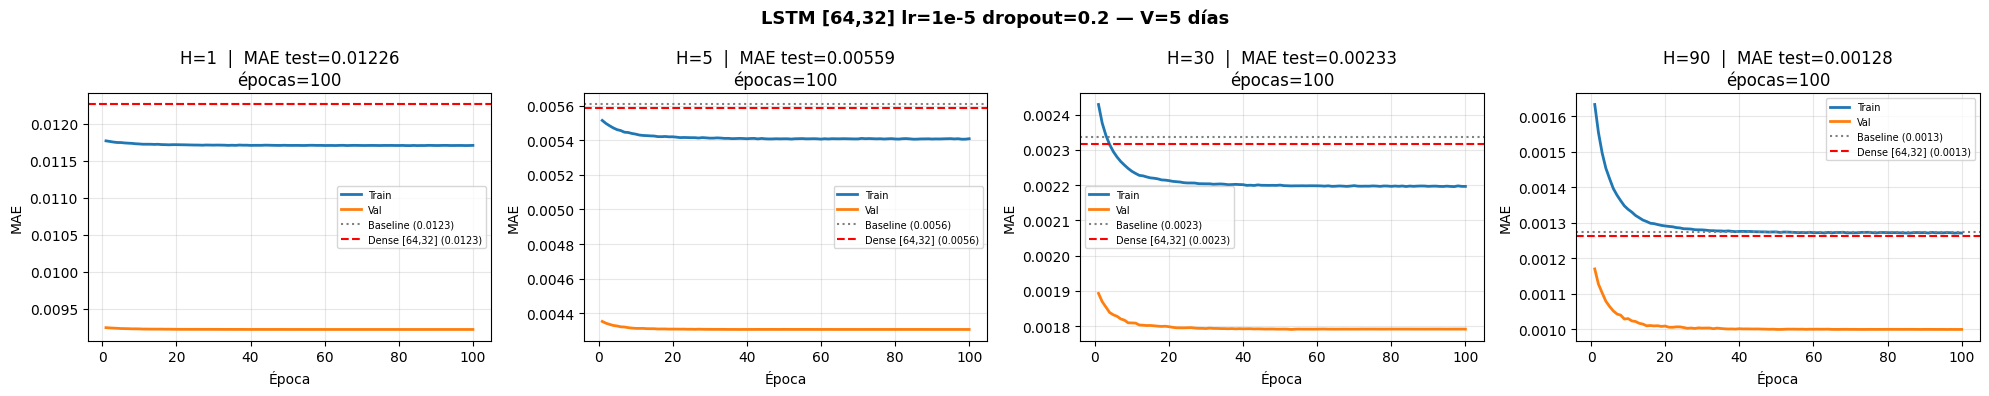

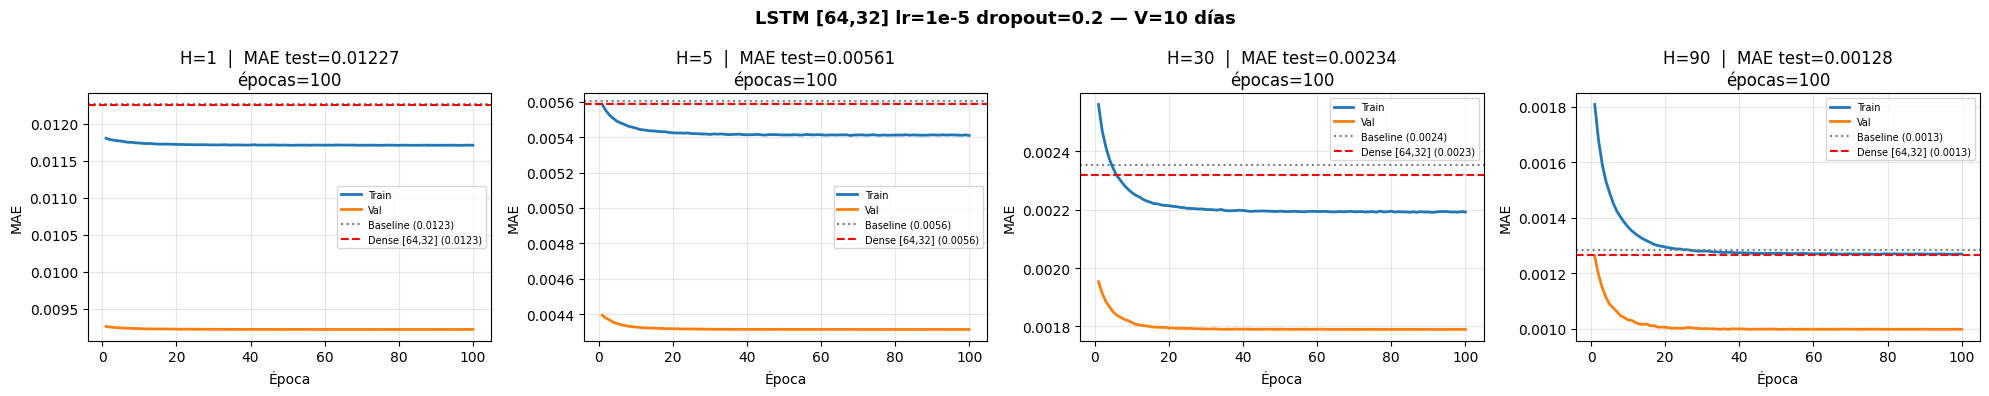

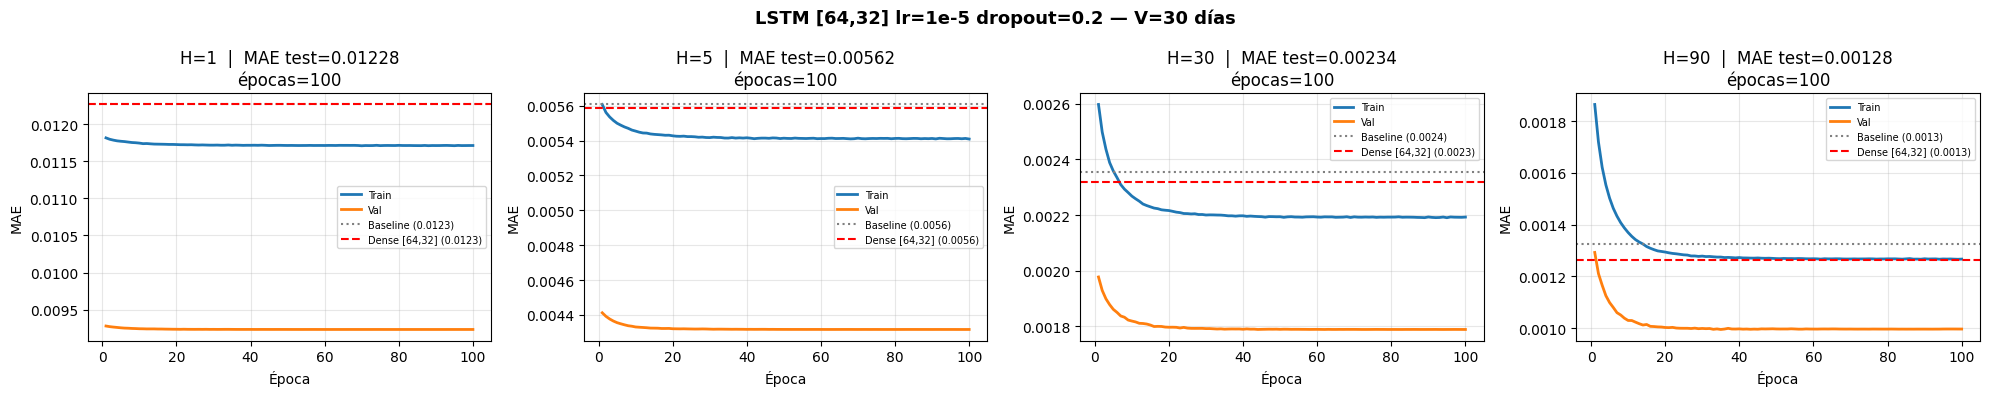

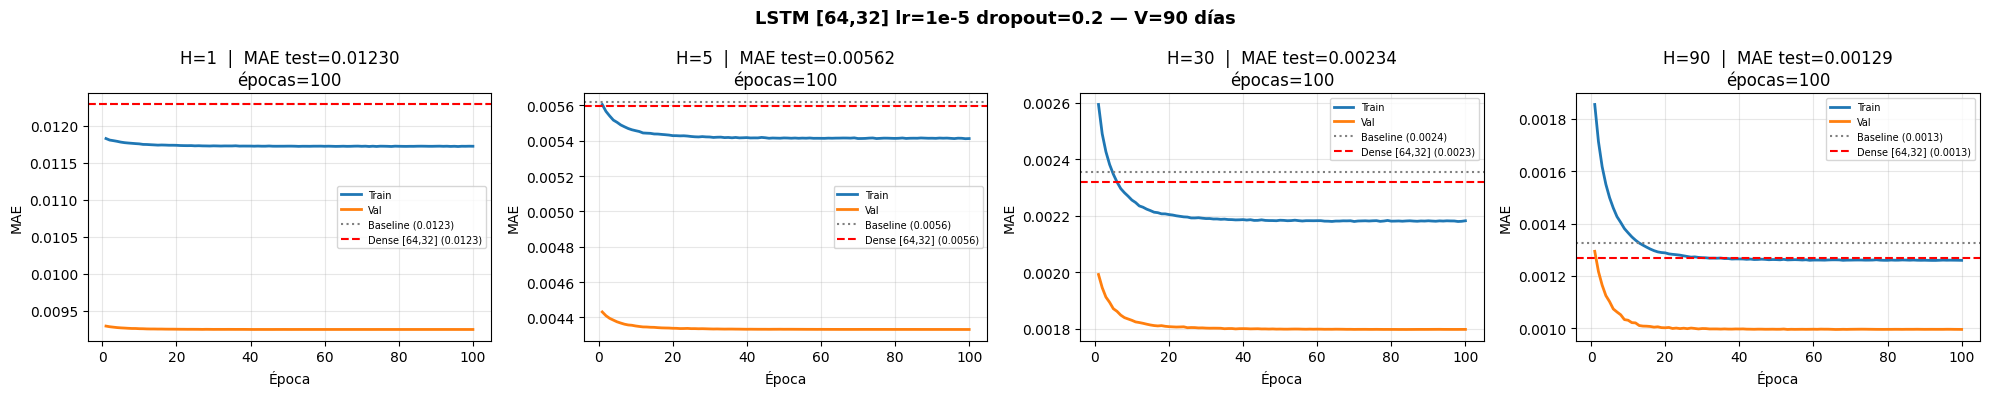

In [6]:
# Una figura por V con 4 subplots (uno por H).
# Línea gris punteada: mejor baseline.
# Línea roja punteada: MLP [64,32] → referencia a superar.
for V in INPUT_WINDOWS:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    for idx, H in enumerate(OUTPUT_WINDOWS):
        clave = f"V{V}_H{H}"
        res   = resultados_lstm[clave]
        hist  = res["history"].history
        ep    = range(1, len(hist["loss"]) + 1)

        ax = axes[idx]
        ax.plot(ep, hist["loss"],     label="Train", linewidth=2)
        ax.plot(ep, hist["val_loss"], label="Val",   linewidth=2)

        # Referencia baseline
        mae_suelo = suelo[(suelo["V"]==V) &
                          (suelo["H"]==H)]["MAE_suelo"].values[0]
        ax.axhline(y=mae_suelo, color="gray", linestyle=":",
                   linewidth=1.5, label=f"Baseline ({mae_suelo:.4f})")

        # Referencia MLP
        mae_mlp = suelo_mlp[(suelo_mlp["V"]==V) &
                             (suelo_mlp["H"]==H)]["MAE_mlp"].values[0]
        ax.axhline(y=mae_mlp, color="red", linestyle="--",
                   linewidth=1.5, label=f"Dense [64,32] ({mae_mlp:.4f})")

        ax.set_title(f"H={H}  |  MAE test={res['mae_test']:.5f}\n"
                     f"épocas={res['epocas']}")
        ax.set_xlabel("Época"); ax.set_ylabel("MAE")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.suptitle(f"LSTM [64,32] lr=1e-5 dropout=0.2 — V={V} días",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"03_lstm_V{V}.png",
                bbox_inches="tight", dpi=120)
    plt.show()

## 5. Resultados y conclusiones

In [7]:
# Construir DataFrame y guardar CSV
resultados_def = [
    {
        "modelo":            "LSTM",
        "V":                 res["V"],
        "H":                 res["H"],
        "MAE_test":          res["mae_test"],
        "n_params":          contar_parametros(
                             build_lstm_model((res["V"], 23), [64, 32],
                                              dropout=0.2)),
        "epocas_entrenadas": res["epocas"],
    }
    for res in resultados_lstm.values()
]

df_lstm = pd.DataFrame(resultados_def).round(6)
df_lstm.to_csv(TABLES_DIR / "03_rnn.csv", index=False)
print(f"Guardado en results/tables/03_rnn.csv")
df_lstm

Guardado en results/tables/03_rnn.csv


,modelo,V,H,MAE_test,n_params,epocas_entrenadas
0,LSTM,5,1,0.012257,35703,100
1,LSTM,5,5,0.005595,35703,100
2,LSTM,5,30,0.002334,35703,100
3,LSTM,5,90,0.001275,35703,100
4,LSTM,10,1,0.012269,35703,100
5,LSTM,10,5,0.005608,35703,100
6,LSTM,10,30,0.002339,35703,100
7,LSTM,10,90,0.001284,35703,100
8,LSTM,30,1,0.012277,35703,100
9,LSTM,30,5,0.005616,35703,100


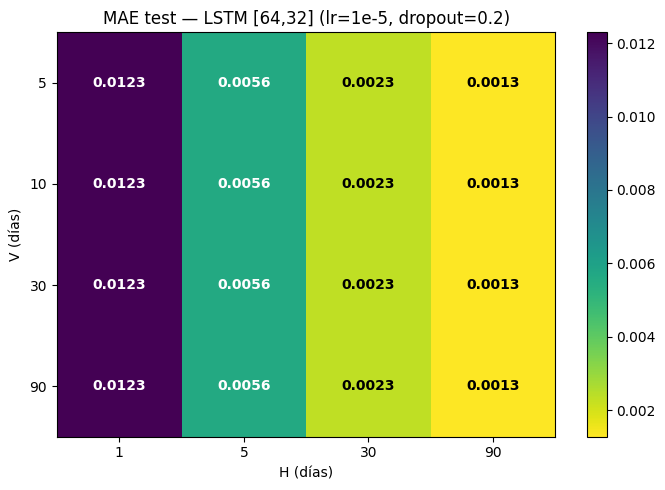

In [8]:
# Matriz 4×4 de MAE en test
matriz = construir_matriz_resultados(
    df_lstm.to_dict("records"), INPUT_WINDOWS, OUTPUT_WINDOWS
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(matriz, cmap="viridis_r", origin="upper", aspect="auto")

for i in range(len(INPUT_WINDOWS)):
    for j in range(len(OUTPUT_WINDOWS)):
        val = matriz[i, j]
        if not np.isnan(val):
            color = "white" if val > np.nanmedian(matriz) else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                    color=color, fontsize=10, fontweight="bold")

ax.set_xticks(range(len(OUTPUT_WINDOWS)))
ax.set_yticks(range(len(INPUT_WINDOWS)))
ax.set_xticklabels(OUTPUT_WINDOWS)
ax.set_yticklabels(INPUT_WINDOWS)
ax.set_xlabel("H (días)"); ax.set_ylabel("V (días)")
ax.set_title("MAE test — LSTM [64,32] (lr=1e-5, dropout=0.2)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_matriz_lstm.png",
            bbox_inches="tight", dpi=120)
plt.show()

In [9]:
# Comparación LSTM vs Dense [64,32] vs Baseline
comparacion = df_lstm.merge(suelo_mlp, on=["V","H"])
comparacion = comparacion.merge(suelo, on=["V","H"])

comparacion["mejora_vs_mlp_%"] = (
    (comparacion["MAE_mlp"] - comparacion["MAE_test"])
    / comparacion["MAE_mlp"] * 100
).round(2)
comparacion["bate_mlp"]      = comparacion["MAE_test"] < comparacion["MAE_mlp"]
comparacion["bate_baseline"] = comparacion["MAE_test"] < comparacion["MAE_suelo"]

print("LSTM [64,32] vs Dense [64,32] vs Baseline:")
print(comparacion[["V","H","MAE_test","MAE_mlp","MAE_suelo",
                    "mejora_vs_mlp_%","bate_mlp",
                    "bate_baseline"]].to_string(index=False))
print()
print(f"LSTM bate al Dense en:    {comparacion['bate_mlp'].sum()}/16 combinaciones")
print(f"LSTM bate al baseline en: {comparacion['bate_baseline'].sum()}/16 combinaciones")

LSTM [64,32] vs Dense [64,32] vs Baseline:
 V  H  MAE_test  MAE_mlp  MAE_suelo  mejora_vs_mlp_%  bate_mlp  bate_baseline
 5  1  0.012257 0.012258   0.012258             0.01      True           True
 5  5  0.005595 0.005586   0.005607            -0.16     False           True
 5 30  0.002334 0.002318   0.002337            -0.69     False           True
 5 90  0.001275 0.001264   0.001274            -0.87     False          False
10  1  0.012269 0.012261   0.012262            -0.07     False          False
10  5  0.005608 0.005585   0.005607            -0.41     False          False
10 30  0.002339 0.002320   0.002354            -0.82     False           True
10 90  0.001284 0.001265   0.001284            -1.50     False          False
30  1  0.012277 0.012269   0.012269            -0.07     False          False
30  5  0.005616 0.005589   0.005611            -0.48     False          False
30 30  0.002340 0.002319   0.002355            -0.91     False           True
30 90  0.001284 0.001

### Conclusiones

#### LSTM vs Dense [64,32]

Anota aquí los resultados reales obtenidos:

- ¿En cuántas combinaciones la LSTM mejora al Dense?
- ¿Para qué horizontes H es más notable la diferencia?
- ¿Las curvas de H=30 y H=90 tienen más pendiente que H=1?

#### Interpretación

**Si LSTM mejora al Dense**: la dependencia temporal existe y la LSTM
la captura. El Flatten del Dense destruía información relevante.

**Si LSTM no mejora al Dense**: los retornos logarítmicos diarios no
contienen dependencias temporales explotables con estas arquitecturas.
El orden de los días no importa para predecir el futuro. Esto es
consistente con la hipótesis de mercado eficiente.

En cualquier caso es un resultado científico válido que documenta
el comportamiento de estos modelos en datos financieros reales.

#### Para el informe

La comparación visual entre las matrices 4×4 del Dense (notebook 02)
y la LSTM (este notebook) cuenta la historia de forma clara.

**Siguiente paso**: notebook 05 — Modelos mixtos (Conv1D + LSTM).
